In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import yfinance as yf

from dotenv import load_dotenv
import os
import sys

In [2]:
load_dotenv()  # carga .env
sys.path.insert(0, os.path.join(os.environ["CUANTIS_ROOT"], "src"))

In [3]:
from cuantis_utils.TimeSeriesHypothesisTester import TimeSeriesHypothesisTester

ModuleNotFoundError: No module named 'cuantis_utils.TimeSeriesHypothesisTester'

In [7]:
pd.options.display.float_format = '{:,.2f}'.format

In [8]:
ticker = "CVX"
start_date = "1990-01-01"
end_date = "2026-02-01"  # yfinance uses an exclusive end date by default

df = yf.download(
    tickers=ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,   # keep Close/Adj Close both, similar to YahooFinancials raw prices
    progress=False
)#.reset_index(),


In [17]:
tester = TimeSeriesHypothesisTester(price_series=df["Adj Close"]["CVX"])  # serie de precios

In [18]:
tester.compute_returns()

,R,r
Date,,
1990-01-03,-0.02,-0.02
1990-01-04,-0.01,-0.01
1990-01-05,-0.01,-0.02
1990-01-08,0.01,0.01
1990-01-09,-0.01,-0.01
...,...,...
2026-01-26,0.00,0.00
2026-01-27,0.01,0.01
2026-01-28,0.01,0.01


In [23]:
tester.test_variance_equality().decision

'Varianzas iguales'

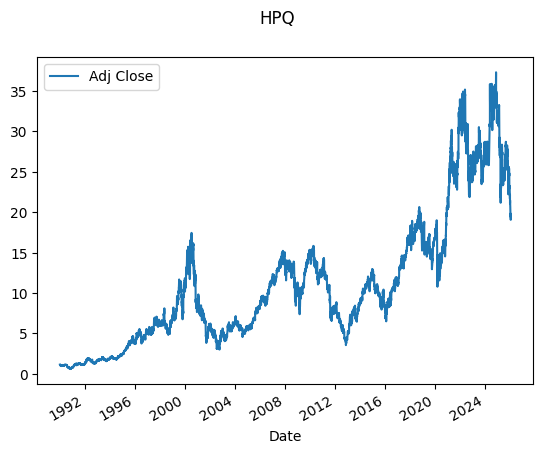

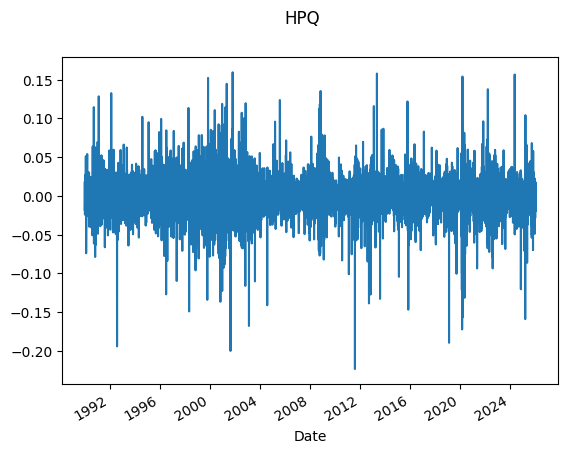

In [2]:

df.columns = df.columns.droplevel(1)
data = pd.DataFrame(df["Adj Close"])

data.plot()
plt.suptitle(ticker)
plt.show()

data["r"]=np.log(df["Adj Close"])-np.log(df["Adj Close"].shift(1))
data= data.dropna()

data.r.plot()
plt.suptitle(ticker)
plt.show()
#%%

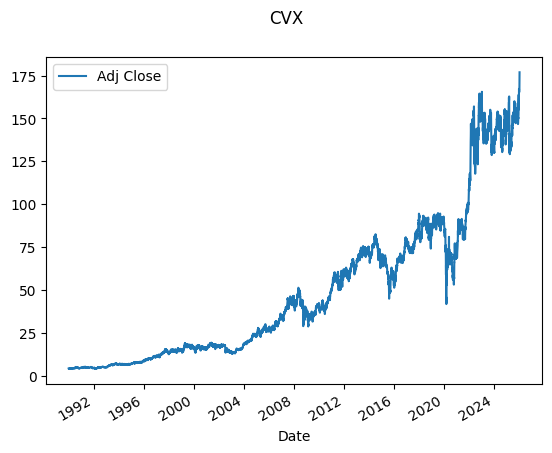

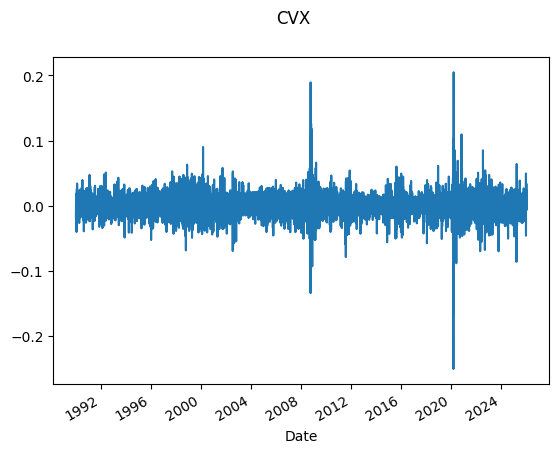

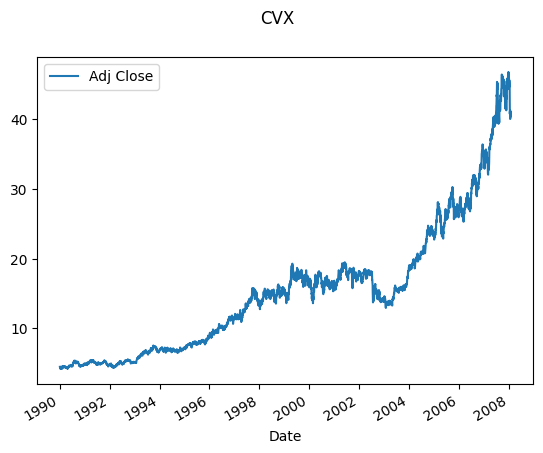

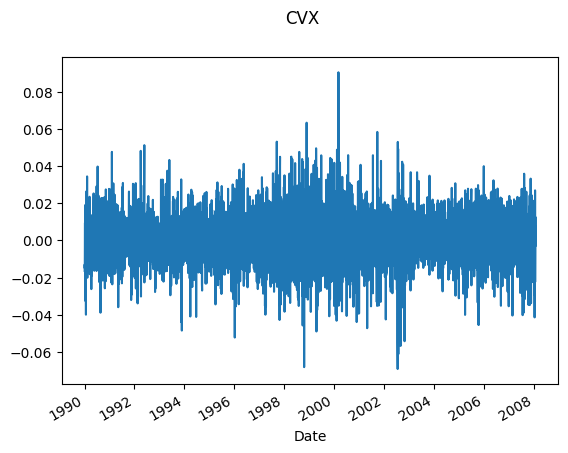

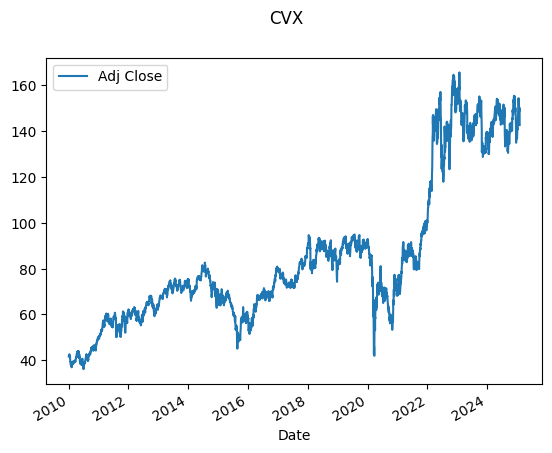

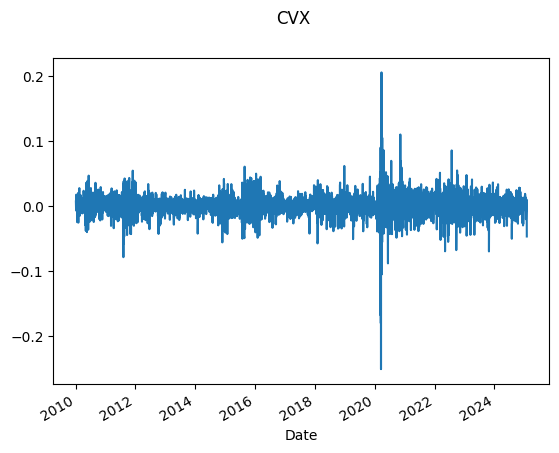

Ho NO puede ser rechazada (Son iguales)
Ho NO puede ser rechazada (Son iguales)


In [3]:
#%%
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Download AMZN
ticker = "CVX"
start_date = "1990-01-01"
end_date = "2026-02-01"  # yfinance uses an exclusive end date by default

df = yf.download(
    tickers=ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,   # keep Close/Adj Close both, similar to YahooFinancials raw prices
    progress=False
)#.reset_index(),
#%%
df.columns = df.columns.droplevel(1)
data = pd.DataFrame(df["Adj Close"])

data.plot()
plt.suptitle(ticker)
plt.show()

data["r"]=np.log(df["Adj Close"])-np.log(df["Adj Close"].shift(1))
data= data.dropna()

data.r.plot()
plt.suptitle(ticker)
plt.show()
#%%
# Sample 1
# ticker = "HPQ"
start_date = "1990-01-01"
end_date = "2008-02-01"  # yfinance uses an exclusive end date by default

df = yf.download(
    tickers=ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,   # keep Close/Adj Close both, similar to YahooFinancials raw prices
    progress=False
)#.reset_index(),

df.columns = df.columns.droplevel(1)
data1 = pd.DataFrame(df["Adj Close"])

data1.plot()
plt.suptitle(ticker)
plt.show()

data1["r"]=np.log(df["Adj Close"])-np.log(df["Adj Close"].shift(1))
data1= data1.dropna()

data1.r.plot()
plt.suptitle(ticker)
plt.show() 
#%%
# Sample 2
start_date = "2010-01-01"
end_date = "2025-02-01"  # yfinance uses an exclusive end date by default

df = yf.download(
    tickers=ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,   # keep Close/Adj Close both, similar to YahooFinancials raw prices
    progress=False
)#.reset_index(),

df.columns = df.columns.droplevel(1)
data2 = pd.DataFrame(df["Adj Close"])

data2.plot()
plt.suptitle(ticker)
plt.show()

data2["r"]=np.log(df["Adj Close"])-np.log(df["Adj Close"].shift(1))
data2= data2.dropna()

data2.r.plot()
plt.suptitle(ticker)
plt.show() 

#%%
# Prueba de varianzas levene
from scipy import stats

alfa= 0.05
#Ho: son igual
#Ha: No son iguales

'Levene'
W, p2 = stats.levene(data1.r, data2.r)
if p2<alfa:
    print('Ho puede ser rechazada (No son iguales)')
else:
    print('Ho NO puede ser rechazada (Son iguales)')
# %%
#Prueba de medias t de student

t, p = stats.ttest_ind(data1.r, data2.r, equal_var=True)

if p<alfa:
    print('Ho puede ser rechazada (No son iguales)')
else:
    print('Ho NO puede ser rechazada (Son iguales)')